# Random Walk

Se tiene $N$ particulas en una vecindad discreta centrada en el punto $x=0$, las particulas evolucionan en el tiempo por movimiento Browniano según la siguiente probabilidad:

\begin{equation}
x(n+1) =
\begin{cases}
x(n) + 1 & \text{con probabilidad} \hphantom{a} p = 0.5 \\
x(n) - 1 & \text{con probabilidad} \hphantom{a} p = 0.5
\end{cases}
\end{equation}

Donde $x$ es la posición en cada paso de tiempo, $p$ es la probabilidad y $n$ el número de pasos. Dado que no existe fuerzas externas o sesgos inducidos de ningún tipo, la probabilidad de ir a la izquierda o a la derecha para la particula es la misma e igual a 0.5.

Se introduce primero el número de particulas $N$ a simular y la cantidad de pasos de tiempo totales $t$.

In [ ]:
N = 100000 # Número de particulas
t = 100000 # Pasos de tiempo

Despues, se define el vector de posición inicial $x(0)$, para esto, se reparten las $N$ particulas de forma aleatoria en [-1, 1], notar que $x$ solo puede tomar valores enteros. Luego, para cada paso de tiempo, desde 1 hasta $t$, cada particula puede desplazarse una unidad a la izquierda o a la derecha con igual probabilidad.

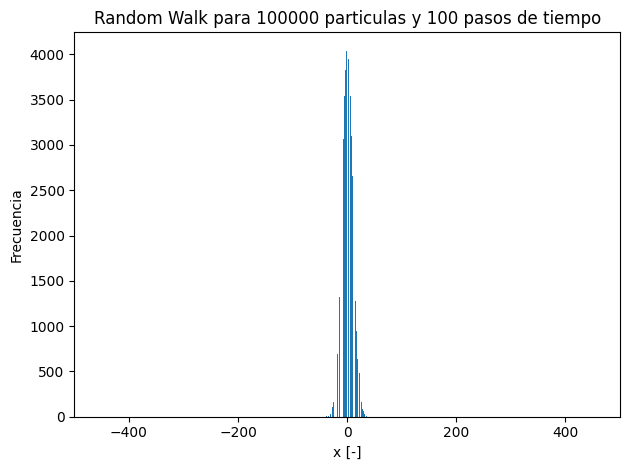

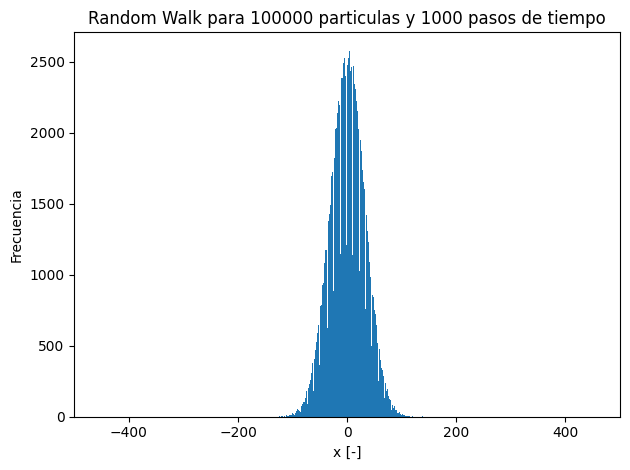

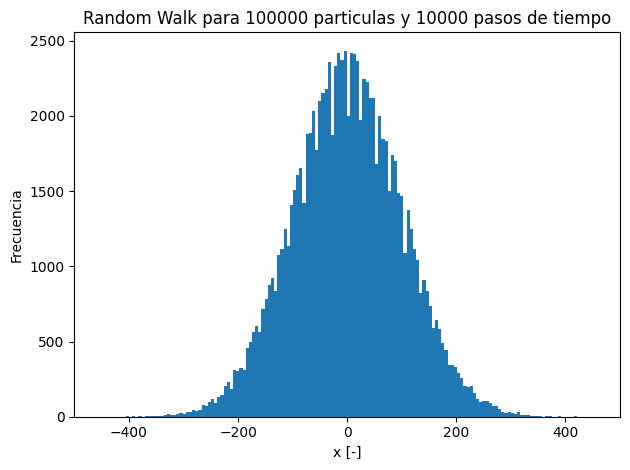

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng()
x = rng.integers(low=0, high=1, size=N, endpoint=True) # Arreglo con las posiciones iniciales, se reparten al azar entre -1 y 1

for k in range(t):
  d = rng.integers(low=1, high=2, size=N, endpoint=True) # Arreglo con el movimiento de cada punto, 2 representa el movimiento a la izquierda.
  d = np.where(d==2, -1, d)
  x+= d
  if k == 100:
    x_10e2 = x
    fig, ax = plt.subplots(1, 1, sharey=True, tight_layout=True)

    ax.hist(x, bins='auto')
    ax.set_xlabel('x [-]')
    ax.set_ylabel('Frecuencia')
    ax.set_xlim(left=-500, right=500)
    ax.set_title(f'Random Walk para {N} particulas y {k} pasos de tiempo')
    plt.show()
  if k == 1000:
    x_10e3 = x
    fig, ax = plt.subplots(1, 1, sharey=True, tight_layout=True)

    ax.hist(x, bins='auto')
    ax.set_xlabel('x [-]')
    ax.set_ylabel('Frecuencia')
    ax.set_xlim(left=-500, right=500)
    ax.set_title(f'Random Walk para {N} particulas y {k} pasos de tiempo')
    plt.show()
  if k == 10000:
    x_10e4 = x
    fig, ax = plt.subplots(1, 1, sharey=True, tight_layout=True)

    ax.hist(x, bins='auto')
    ax.set_xlabel('x [-]')
    ax.set_ylabel('Frecuencia')
    ax.set_xlim(left=-500, right=500)
    ax.set_title(f'Random Walk para {N} particulas y {k} pasos de tiempo')
    plt.show()

A continuación se muestra la distribución de las particulas una vez transcurridos los $t$ pasos de tiempo.

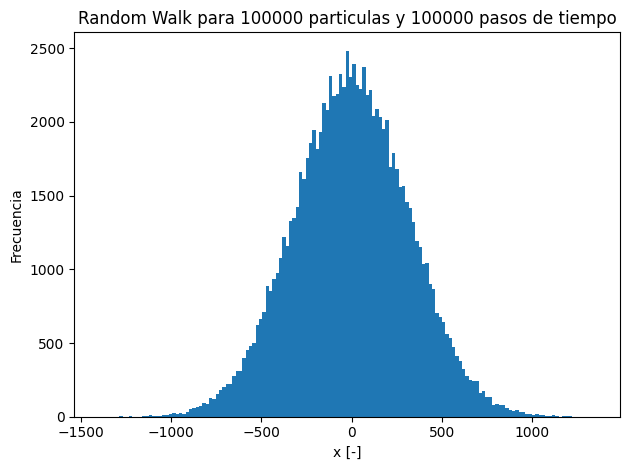

In [ ]:
fig, ax = plt.subplots(1, 1, sharey=True, tight_layout=True)

ax.hist(x, bins='auto')
ax.set_xlabel('x [-]')
ax.set_ylabel('Frecuencia')
#ax.set_xlim(left=-1500, right=1500)
ax.set_title(f'Random Walk para {N} particulas y {t} pasos de tiempo')
plt.show()

Según la teoría de movimiento Browniano para sistemas discretos con $N$ "muy grande" se sabe que la desviación estandar de la diferencia de pasos $m$ esta dada por:

\begin{equation}
\sigma_{m} = \sqrt{N}
\end{equation}

Mientras que la desviación estandar de la ddistribución se obtiene como:

\begin{equation}
\sigma_{r} = l \cdot \sigma_{m}
\end{equation}

Donde $l$ es la distancia característica del problema, en este caso, corresponde al desplazamiento permitido por cada paso de tiempo, es decir, $l = 1$. De esta manera, es posible obtener la curva Gausseana que mejor se ajusta a la distribución tomando la desviación estandar calculada.

In [ ]:
def gauss(x, mu, sigma):
  return 1/(sigma*np.sqrt(2*np.pi)) * np.exp(-(x-mu)**2/(2*sigma**2))

In [ ]:
l = 1
D = N*l**2 / (2*t)

mu = 0
sigma_m = np.sqrt(N)
sigma_r = l * sigma_m

sigma = np.sqrt(2*D*t)

gauss = np.random.normal(mu, sigma, N)

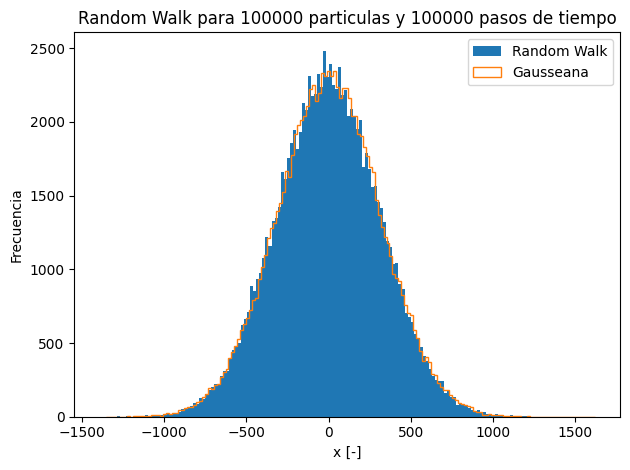

In [ ]:
fig, ax = plt.subplots(1, 1, sharey=True, tight_layout=True)

ax.hist(x, bins='auto', label='Random Walk')
ax.hist(gauss, bins='auto', label='Gausseana', histtype='step')
ax.set_xlabel('x [-]')
ax.set_ylabel('Frecuencia')
ax.set_title(f'Random Walk para {N} particulas y {t} pasos de tiempo')
plt.legend()
plt.show()